# 09 · Transformer: Attention을 학습 가능한 블록으로 조합하기

**질문:** Attention 하나에 위치, 여러 비교 공간, 정규화, 잔차, 위치별 MLP를 붙이면 전체 backward는 어떻게 연결될까요?

이 노트북은 **한 블록의 Pre-LayerNorm Transformer**를 NumPy로 구현합니다. 각 부품과 전체 입력·모든 파라미터의 미분을 검사하고, 길이 4 토큰열을 뒤집는 지도학습을 진행합니다. 08 Attention의 Q·K·V와 mask를 먼저 확인하세요. 처음에는 1–3절, 다음에는 4–7절로 나누어 공부해도 됩니다.

원 논문의 Post-LayerNorm 배치와는 다르게, 각 하위 층에 들어가기 전에 정규화하는 Pre-LayerNorm을 사용합니다. 아래에 구현한 식이 기준입니다. 큰 언어모델의 학습·생성까지 재현하는 노트북은 아닙니다.

[그림 보조 파일](../../src/utils/architecture_plots.py) · [이전 Attention](08_attention.ipynb) · [전체 경로](../../docs/CURRICULUM.md)

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.architecture_plots import plot_matrices, plot_curves
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· Transformer 준비 완료")

NumPy 2.3.5 · Transformer 준비 완료


## 1. LayerNorm: 토큰 하나의 특성 좌표를 정규화하기

$X$의 shape는 `(N,T,D)`입니다. 평균과 분산을 **마지막 D축**에 대해서만 구합니다. 배치 간 통계를 섞는 BatchNorm과 다릅니다.
$$\mu=\frac1D\sum_jx_j,\quad v=\frac1D\sum_j(x_j-\mu)^2,\quad
\hat x=(x-\mu)/\sqrt{v+\epsilon},\quad y=\gamma\odot\hat x+\beta.$$

$\gamma,\beta$는 `(D,)`의 학습 파라미터입니다. `keepdims=True`로 평균·분산의 shape를 `(N,T,1)`로 남기면 모든 특성 좌표에 맞춰 broadcast됩니다. $\epsilon>0$이면 $\hat x$의 분산은 정확히 1이 아니라 $v/(v+\epsilon)$입니다.

Backward에서 $u=dy\odot\gamma$, $r=(v+\epsilon)^{-1/2}$라 놓으면
$$dx=r\left[u-mean_D(u)-\hat x\,mean_D(u\odot\hat x)\right].$$
세 항은 각각 x의 직접 경로, 평균을 뺀 경로, 분산을 거친 경로입니다. 더 풀어 보면 $d\hat x=u$, $dv=\sum_j u_j(x_j-\mu)(-\frac12)(v+\epsilon)^{-3/2}$입니다. $dv$에서 $x-\mu$로 돌아온 항을 직접 항 $u r$에 더하고 그 평균을 빼면 위 식이 나옵니다.
$$d\gamma=\sum_{n,t}dy\odot\hat x,\quad d\beta=\sum_{n,t}dy.$$

In [2]:
def layernorm_forward(X, gamma, beta, eps=1e-5):
    centered = X - X.mean(axis=-1, keepdims=True)
    inverse = 1 / np.sqrt(np.mean(centered ** 2, axis=-1, keepdims=True) + eps)
    normalized = centered * inverse
    return normalized * gamma + beta, (normalized, inverse, gamma)


def layernorm_backward(dY, cache):
    normalized, inverse, gamma = cache
    u = dY * gamma
    dX = inverse * (u - u.mean(axis=-1, keepdims=True)
                    - normalized * (u * normalized).mean(axis=-1, keepdims=True))
    axes = tuple(range(dY.ndim - 1))
    return dX, np.sum(dY * normalized, axis=axes), np.sum(dY, axis=axes)


def check_layernorm(candidate):
    rng = np.random.default_rng(91)
    X = rng.normal(size=(2, 3, 4))
    gamma, beta = rng.normal(size=4), rng.normal(size=4)
    Y, cache = layernorm_forward(X, gamma, beta, eps=0.07)
    G = rng.normal(size=Y.shape)
    dx, dg, db = candidate(G, cache)
    scalar = lambda: float(np.sum(layernorm_forward(X, gamma, beta, eps=0.07)[0] * G))
    errors = {name: rel_error(grad, numerical_gradient(scalar, value))
              for name, value, grad in [("X", X, dx), ("gamma", gamma, dg), ("beta", beta, db)]}
    assert all(np.isfinite(e) and e < 2e-6 for e in errors.values()), errors
    return errors

In [3]:
ln_errors = check_layernorm(layernorm_backward)
print("LayerNorm 최대 상대오차:", max(ln_errors.values()))
ln_X = np.array([[[1., 2., 4., 9.], [4., 5., 7., 12.]]])
ln_Y, _ = layernorm_forward(ln_X, np.ones(4), np.zeros(4))
np.testing.assert_allclose(ln_Y.mean(axis=-1), 0., atol=1e-12)
np.testing.assert_allclose(ln_Y[:, 0], ln_Y[:, 1], atol=1e-12)

LayerNorm 최대 상대오차: 3.266358006395601e-10


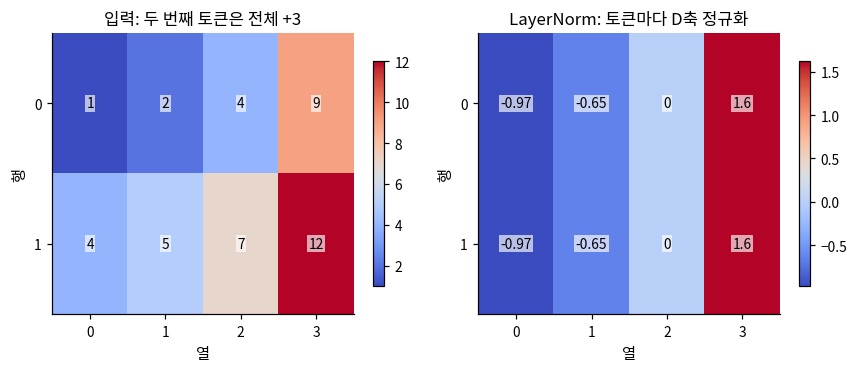

In [4]:
plot_matrices([ln_X[0], ln_Y[0]], ["입력: 두 번째 토큰은 전체 +3", "LayerNorm: 토큰마다 D축 정규화"])

전체 좌표에 같은 수를 더한 차이는 사라집니다. 따라서 LayerNorm은 정보를 무조건 보존하는 연산이 아닙니다. Transformer는 잔차 경로로 원래 입력을 함께 전달합니다.

## 2. Multi-head attention: 축을 나누고 다시 모으기

모델 폭 D를 head 수 A로 나누어 $d_h=D/A$로 둡니다. A로 나누어떨어지는 D만 사용합니다. Q·K·V를 각각 `(N,T,D)`로 투영한 뒤
`(N,T,D) → reshape(N,T,A,dh) → transpose(N,A,T,dh)`로 바꿉니다.

각 head에서 독립적으로 $softmax(QK^T/\sqrt{d_h})V$를 계산합니다. 결과를 원래 축 순서로 합쳐 `(N,T,D)`로 만들고 $W_o$로 섞습니다. **각 head에 전체 D를 복사하는 구현이 아니라, 서로 다른 학습 좌표 묶음을 나누는 구현**입니다.

공유 mask는 `(T,T)`, 배치마다 다른 mask는 `(N,1,T,T)`로 줍니다. 가운데 1은 head 축에 공통으로 적용한다는 뜻입니다. `(N,T,T)`를 그대로 broadcast하면 N과 head 수가 같을 때 배치 축이 head 축에 잘못 맞아도 실행될 수 있어 이 구현에서는 거부합니다.

MHA backward는 출력 투영 → head 분리 → 각 head attention backward → head 합치기 → Q/K/V 입력 투영의 역순입니다. 입력 X는 세 투영으로 갈라졌으므로 $dX=dQW_q^T+dKW_k^T+dVW_v^T$로 더합니다.

In [5]:
def split_heads(X, heads):
    N, T, D = X.shape
    assert D % heads == 0
    return X.reshape(N, T, heads, D // heads).transpose(0, 2, 1, 3)


def merge_heads(X):
    N, heads, T, width = X.shape
    return X.transpose(0, 2, 1, 3).reshape(N, T, heads * width)


def attention_forward(Q, K, V, allowed=None):
    scale = np.sqrt(Q.shape[-1])
    S = Q @ K.swapaxes(-1, -2) / scale
    if allowed is None:
        mask = np.ones(S.shape, dtype=bool)
    else:
        allowed = np.asarray(allowed, dtype=bool)
        if allowed.ndim not in (2, 4):
            raise ValueError("MHA mask는 (T,T) 또는 (N,1,T,T)처럼 head 축을 명시해야 합니다")
        mask = np.broadcast_to(allowed, S.shape)
    if not np.all(mask.any(axis=-1)):
        raise ValueError("각 query에 허용된 key가 하나 이상 필요합니다")
    S = np.where(mask, S, -np.inf)
    exps = np.exp(S - S.max(axis=-1, keepdims=True))
    P = exps / exps.sum(axis=-1, keepdims=True)
    return P @ V, (Q, K, V, P, mask, scale)


def attention_backward(dO, cache):
    Q, K, V, P, mask, scale = cache
    dP = dO @ V.swapaxes(-1, -2)
    dS = P * (dP - (dP * P).sum(axis=-1, keepdims=True))
    dS = np.where(mask, dS, 0.)
    return dS @ K / scale, dS.swapaxes(-1, -2) @ Q / scale, P.swapaxes(-1, -2) @ dO


def mha_forward(X, p, heads=2, allowed=None):
    Q, K, V = [split_heads(X @ p[k], heads) for k in ["Wq", "Wk", "Wv"]]
    O, attention_cache = attention_forward(Q, K, V, allowed)
    joined = merge_heads(O)
    return joined @ p["Wo"], (X, joined, attention_cache, heads)


def mha_backward(dY, cache, p):
    X, joined, attention_cache, heads = cache
    D = X.shape[-1]
    grads = {"Wo": joined.reshape(-1, D).T @ dY.reshape(-1, D)}
    dO = split_heads(dY @ p["Wo"].T, heads)
    dQ, dK, dV = [merge_heads(g) for g in attention_backward(dO, attention_cache)]
    dX = np.zeros_like(X)
    for name, grad in zip(["Wq", "Wk", "Wv"], [dQ, dK, dV]):
        grads[name] = X.reshape(-1, D).T @ grad.reshape(-1, D)
        dX += grad @ p[name].T
    return dX, grads

In [6]:
rng = np.random.default_rng(92)
head_X = rng.normal(size=(2, 3, 4))
np.testing.assert_array_equal(merge_heads(split_heads(head_X, 2)), head_X)
head_p = {k: rng.normal(size=(4, 4)) * 0.3 for k in ["Wq", "Wk", "Wv", "Wo"]}
causal3 = np.arange(3)[None, :] <= np.arange(3)[:, None]
head_Y, head_cache = mha_forward(head_X, head_p, 2, causal3)
head_G = rng.normal(size=head_Y.shape)
head_dx, head_grads = mha_backward(head_G, head_cache, head_p)
scalar = lambda: float(np.sum(mha_forward(head_X, head_p, 2, causal3)[0] * head_G))
mha_errors = {k: rel_error(head_grads[k], numerical_gradient(scalar, v)) for k, v in head_p.items()}
mha_errors["X"] = rel_error(head_dx, numerical_gradient(scalar, head_X))
assert max(mha_errors.values()) < 2e-6
print("MHA의 입력·네 투영 미분 최대 상대오차:", max(mha_errors.values()))
per_example_mask = np.stack([causal3, np.eye(3, dtype=bool)])
try:
    mha_forward(head_X, head_p, 2, per_example_mask)
except ValueError as error:
    print("예상한 mask shape 거부:", error)
else:
    raise AssertionError("배치·head 축 혼동을 놓쳤습니다")
_, per_example_cache = mha_forward(head_X, head_p, 2, per_example_mask[:, None])
weights = per_example_cache[2][3]
for n in range(2):
    assert np.all(weights[n, :, ~per_example_mask[n]] == 0)
print("배치마다 다른 mask를 모든 head에 적용하는 검산 통과")

MHA의 입력·네 투영 미분 최대 상대오차: 1.3941559756060622e-09
예상한 mask shape 거부: MHA mask는 (T,T) 또는 (N,1,T,T)처럼 head 축을 명시해야 합니다
배치마다 다른 mask를 모든 head에 적용하는 검산 통과


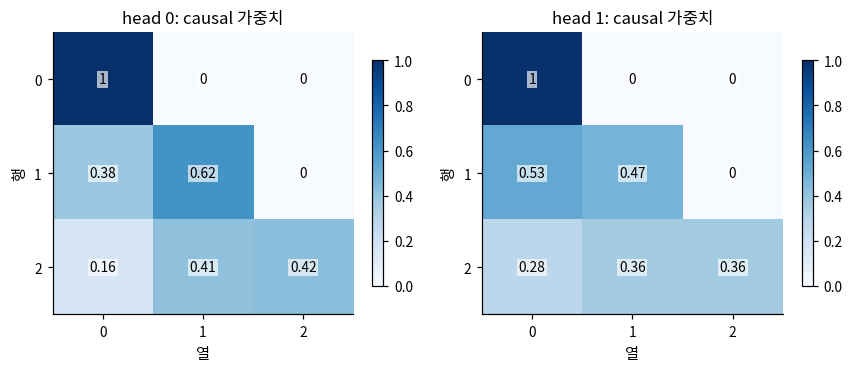

In [7]:
plot_matrices([head_cache[2][3][0, h] for h in range(2)],
              ["head 0: causal 가중치", "head 1: causal 가중치"], cmap="Blues")

## 3. 잔차와 위치별 FFN의 전체 블록

이 노트북의 블록은 다음 식입니다.
$$A=LN_1(X),\quad U=X+MHA(A),$$
$$B=LN_2(U),\quad F=ReLU(BW_1+b_1)W_2+b_2,\quad Y=U+F.$$

FFN은 각 위치에 **같은 MLP**를 적용하며 그 자체로 다른 위치를 읽지 않습니다. 위치 간 정보 교환은 MHA에서 일어납니다. $W_1:(D,D_{ff}),W_2:(D_{ff},D)$입니다.

잔차 $Y=U+F(U)$의 backward는 $dU=dY+(\partial F/\partial U)^TdY$입니다. 첫 항은 항등 경로입니다. 아래 코드의 `dU = dY + dU_norm`에서 dY가 마지막 잔차의 직접 기여입니다. `return dU + dX_norm`에서는 dU가 첫 잔차의 직접 기여이며, 각 하위 층을 거친 미분을 더합니다.

ReLU는 0에서 미분이 유일하지 않아 코드에서는 0을 선택합니다. 수치미분 검사는 꺾임을 가로지르지 않는 작은 임의 입력에서 수행합니다.

In [8]:
def ffn_forward(X, p):
    Z = X @ p["W1"] + p["b1"]
    A = np.maximum(Z, 0)
    return A @ p["W2"] + p["b2"], (X, Z, A)


def ffn_backward(dY, cache, p):
    X, Z, A = cache
    dZ = (dY @ p["W2"].T) * (Z > 0)
    grads = {"W2": A.reshape(-1, A.shape[-1]).T @ dY.reshape(-1, dY.shape[-1]),
             "b2": dY.sum(axis=(0, 1)),
             "W1": X.reshape(-1, X.shape[-1]).T @ dZ.reshape(-1, dZ.shape[-1]),
             "b1": dZ.sum(axis=(0, 1))}
    return dZ @ p["W1"].T, grads


def block_forward(X, p, heads=2, allowed=None):
    A, ln1 = layernorm_forward(X, p["gamma1"], p["beta1"])
    M, mha = mha_forward(A, p, heads, allowed)
    U = X + M
    B, ln2 = layernorm_forward(U, p["gamma2"], p["beta2"])
    F, ffn = ffn_forward(B, p)
    return U + F, (ln1, mha, ln2, ffn)


def block_backward(dY, cache, p):
    ln1, mha, ln2, ffn = cache
    dB, grads = ffn_backward(dY, ffn, p)
    dU_norm, grads["gamma2"], grads["beta2"] = layernorm_backward(dB, ln2)
    dU = dY + dU_norm
    dA, mha_grads = mha_backward(dU, mha, p)
    grads.update(mha_grads)
    dX_norm, grads["gamma1"], grads["beta1"] = layernorm_backward(dA, ln1)
    return dU + dX_norm, grads


def init_block(D=12, hidden=24, seed=93):
    rng = np.random.default_rng(seed)
    p = {k: rng.normal(size=(D, D)) / np.sqrt(D) for k in ["Wq", "Wk", "Wv", "Wo"]}
    p.update({"gamma1": np.ones(D), "beta1": np.zeros(D), "gamma2": np.ones(D), "beta2": np.zeros(D),
              "W1": rng.normal(size=(D, hidden)) * np.sqrt(2 / D), "b1": np.zeros(hidden),
              "W2": rng.normal(size=(hidden, D)) / np.sqrt(hidden), "b2": np.zeros(D)})
    return p


def check_block_backward(candidate):
    X = np.random.default_rng(94).normal(size=(2, 3, 4))
    p = init_block(4, 6, 95)
    Y, cache = block_forward(X, p)
    G = np.random.default_rng(96).normal(size=Y.shape)
    dX, grads = candidate(G, cache, p)
    scalar = lambda: float(np.sum(block_forward(X, p)[0] * G))
    errors = {k: rel_error(grads[k], numerical_gradient(scalar, v)) for k, v in p.items()}
    errors["X"] = rel_error(dX, numerical_gradient(scalar, X))
    assert all(np.isfinite(e) and e < 2e-6 for e in errors.values()), errors
    return errors

In [9]:
block_errors = check_block_backward(block_backward)
print("Transformer 블록 전체 미분 최대 상대오차:", max(block_errors.values()))
# 잔차를 직접 확인: MHA 출력과 FFN 출력을 모두 0으로 만들면 블록은 항등입니다.
identity_p = init_block(4, 6)
identity_p["Wo"][:] = 0
identity_p["W2"][:] = 0
identity_p["b2"][:] = 0
identity_X = rng.normal(size=(2, 3, 4))
identity_Y, identity_cache = block_forward(identity_X, identity_p)
identity_G = rng.normal(size=identity_Y.shape)
identity_dX, _ = block_backward(identity_G, identity_cache, identity_p)
np.testing.assert_allclose(identity_Y, identity_X)
np.testing.assert_allclose(identity_dX, identity_G)
print("두 잔차의 항등 forward·backward 검산 통과")

Transformer 블록 전체 미분 최대 상대오차:

 6.892493636954047e-10
두 잔차의 항등 forward·backward 검산 통과


## 4. 위치와 embedding: 정수 인덱스를 실수 벡터로

정수 토큰 `tokens:(N,T)`는 embedding 표 $E:(V,D)$의 행을 고릅니다. `E[tokens]`의 결과는 `(N,T,D)`입니다. 이는 one-hot과 E를 행렬곱한 것과 같습니다. **정수 인덱스는 미분하지 않고, 선택된 E의 행으로 미분을 누적**합니다.

같은 토큰이 여러 번 나올 수 있어 `dE[tokens] += dX`라는 고급 인덱싱은 반복 인덱스의 누적을 놓칠 수 있습니다. `np.add.at(dE,tokens,dX)`는 각 등장 위치를 모두 더합니다. 아래 전체 검사는 반복 토큰을 포함합니다.

위치가 없고 mask도 없으면 self-attention·LayerNorm·위치별 FFN의 조합은 입력의 순열에 따라 출력도 같은 순열로 바뀝니다. 그래서 절대 위치별 뒤집기를 학습하려면 위치 정보가 필요합니다.

원 논문의 고정 sinusoidal 위치는
$$PE(t,2i)=\sin(t/10000^{2i/D}),\quad PE(t,2i+1)=\cos(t/10000^{2i/D})$$
입니다. 아래에서 직접 그려 봅니다. **완성 학습 실험은 별도의 학습 가능한 위치 표 P를 사용**합니다. $X=E[tokens]+P[:T]$이며, P의 미분은 해당 위치의 배치 합입니다. 둘은 위치를 넣는 대안이며 이번 모델에 두 표를 함께 더하지 않습니다.

In [10]:
def sinusoidal_positions(T, D):
    assert D % 2 == 0
    positions = np.arange(T)[:, None]
    even = np.arange(0, D, 2)[None, :]
    angles = positions / (10000 ** (even / D))
    result = np.empty((T, D))
    result[:, 0::2], result[:, 1::2] = np.sin(angles), np.cos(angles)
    return result


def init_transformer(vocab=4, length=4, D=12, hidden=24, seed=97):
    p = init_block(D, hidden, seed)
    rng = np.random.default_rng(seed + 1)
    p.update({"E": rng.normal(size=(vocab, D)) * 0.2, "P": rng.normal(size=(length, D)) * 0.2,
              "Wout": rng.normal(size=(D, vocab)) / np.sqrt(D), "bout": np.zeros(vocab)})
    return p


def transformer_forward(tokens, p, heads=2, allowed=None, use_positions=True):
    N, T = tokens.shape
    X = p["E"][tokens]
    if use_positions:
        assert T <= len(p["P"]), "학습 위치 표 길이를 넘었습니다"
        X = X + p["P"][:T]
    Y, cache = block_forward(X, p, heads, allowed)
    logits = Y @ p["Wout"] + p["bout"]
    return logits, (tokens, Y, cache, use_positions)


def transformer_backward(dlogits, cache, p, block_backward_fn=block_backward):
    tokens, Y, block_cache, use_positions = cache
    D = Y.shape[-1]
    dX, grads = block_backward_fn(dlogits @ p["Wout"].T, block_cache, p)
    grads["Wout"] = Y.reshape(-1, D).T @ dlogits.reshape(-1, dlogits.shape[-1])
    grads["bout"] = dlogits.sum(axis=(0, 1))
    grads["E"] = np.zeros_like(p["E"])
    np.add.at(grads["E"], tokens, dX)
    grads["P"] = np.zeros_like(p["P"])
    if use_positions:
        grads["P"][:tokens.shape[1]] = dX.sum(axis=0)
    return grads


def token_ce(logits, targets):
    N, T, V = logits.shape
    z, y = logits.reshape(-1, V), targets.reshape(-1)
    shifted = z - z.max(axis=-1, keepdims=True)
    logp = shifted - np.log(np.exp(shifted).sum(axis=-1, keepdims=True))
    grad = np.exp(logp)
    grad[np.arange(N * T), y] -= 1
    return -logp[np.arange(N * T), y].mean(), (grad / (N * T)).reshape(N, T, V)


def check_transformer(block_backward_fn=block_backward):
    tokens = np.array([[0, 1, 0], [2, 1, 1]])
    targets = tokens[:, ::-1]
    p = init_transformer(3, 3, 4, 6, 98)
    logits, cache = transformer_forward(tokens, p)
    _, dlogits = token_ce(logits, targets)
    grads = transformer_backward(dlogits, cache, p, block_backward_fn)
    scalar = lambda: float(token_ce(transformer_forward(tokens, p)[0], targets)[0])
    errors = {k: rel_error(grads[k], numerical_gradient(scalar, v)) for k, v in p.items()}
    assert all(np.isfinite(e) and e < 2e-6 for e in errors.values()), errors
    return errors

In [11]:
position_grid = sinusoidal_positions(12, 12)
np.testing.assert_allclose(position_grid[0, 0::2], 0.)
np.testing.assert_allclose(position_grid[0, 1::2], 1.)
transformer_errors = check_transformer()
print("embedding·위치·head까지 모든 파라미터 최대 상대오차:", max(transformer_errors.values()))

embedding·위치·head까지 모든 파라미터 최대 상대오차: 1.4834569676899003e-09


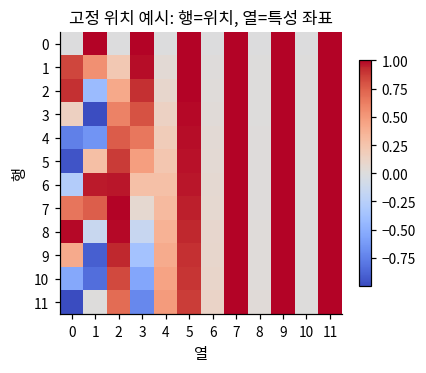

In [12]:
plot_matrices([position_grid], ["고정 위치 예시: 행=위치, 열=특성 좌표"], annotate=False)

## 5. 완성 학습: 네 토큰을 역순으로 바꾸기

예를 들어 `[0,3,1,2] → [2,1,3,0]`입니다. 입력 네 토큰 전체를 보고 출력 네 토큰을 동시에 분류합니다. **양방향 attention**을 사용하므로 미래 위치도 읽을 수 있습니다. 여기서 causal mask를 씌우면 첫 출력이 마지막 입력을 읽을 수 없어 문제의 정보 조건이 달라집니다.

4종 기호의 길이 4 조합 $4^4=256$개를 생성하고, 192개는 학습·64개는 검증으로 분리합니다. 같은 토큰열이 양쪽에 들어가지 않습니다. 학습은 800스텝, 배치 64, Adam 학습률 0.01입니다. 목적은 $NT$개 위치의 평균 CE이며, 지표는 **토큰별 정확도**와 **네 위치 모두 맞힌 문장 정확도**를 함께 봅니다.

가변 길이 padding은 이 실험에 없습니다. padding을 추가하면 key mask와 함께 유효 target 위치만 손실에 포함하고 그 개수로 평균내야 합니다. 마지막 코드의 `/ (N*T)`를 그대로 쓰면 평균의 의미가 달라집니다.

In [13]:
from itertools import product

def adam_step(p, grads, state, step, lr=0.01):
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]
        v = 0.999 * v + 0.001 * grads[key] ** 2
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)

In [14]:
all_tokens = np.array(list(product(range(4), repeat=4)))
order = np.random.default_rng(901).permutation(len(all_tokens))
train_tokens, valid_tokens = all_tokens[order[:192]], all_tokens[order[192:]]
train_targets, valid_targets = train_tokens[:, ::-1], valid_tokens[:, ::-1]
assert set(map(tuple, train_tokens)).isdisjoint(set(map(tuple, valid_tokens)))
p = init_transformer()
state = {k: (np.zeros_like(v), np.zeros_like(v)) for k, v in p.items()}
rng_train = np.random.default_rng(902)
history = {"step": [], "train": [], "valid": []}
for step in range(801):
    if step % 80 == 0:
        train_logits, _ = transformer_forward(train_tokens, p)
        valid_logits, _ = transformer_forward(valid_tokens, p)
        history["step"].append(step)
        history["train"].append(token_ce(train_logits, train_targets)[0])
        history["valid"].append(token_ce(valid_logits, valid_targets)[0])
    if step == 800:
        break
    batch = rng_train.choice(len(train_tokens), 64, replace=False)
    logits, cache = transformer_forward(train_tokens[batch], p)
    loss, dlogits = token_ce(logits, train_targets[batch])
    grads = transformer_backward(dlogits, cache, p)
    norm = np.sqrt(sum(np.sum(g * g) for g in grads.values()))
    scale = min(1., 1. / (norm + 1e-12))
    adam_step(p, {k: g * scale for k, g in grads.items()}, state, step + 1)
predictions = valid_logits.argmax(axis=-1)
token_accuracy = np.mean(predictions == valid_targets)
sequence_accuracy = np.mean(np.all(predictions == valid_targets, axis=1))
print("파라미터", sum(v.size for v in p.values()))
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}")
print(f"검증 CE {history['valid'][-1]:.6f}, 토큰 {token_accuracy:.1%}, 문장 {sequence_accuracy:.1%}")
print("입력 / 정답 / 예측")
for x, y, pred in zip(valid_tokens[:5], valid_targets[:5], predictions[:5]):
    print(x, "/", y, "/", pred)
assert token_accuracy > 0.95 and sequence_accuracy > 0.9

파라미터 1384
학습 CE 1.554663 → 0.000001
검증 CE 0.000002, 토큰 100.0%, 문장 100.0%
입력 / 정답 / 예측
[3 0 1 3] / [3 1 0 3] / [3 1 0 3]
[1 2 1 2] / [2 1 2 1] / [2 1 2 1]
[0 3 0 2] / [2 0 3 0] / [2 0 3 0]
[1 1 3 0] / [0 3 1 1] / [0 3 1 1]
[1 0 3 1] / [1 3 0 1] / [1 3 0 1]


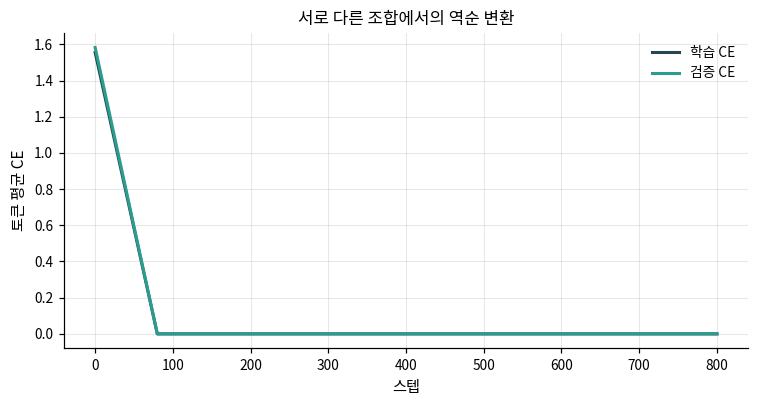

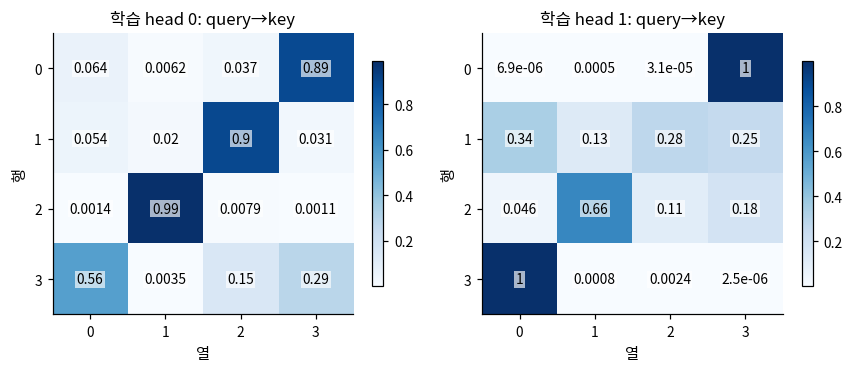

In [15]:
plot_curves(history["step"], {"학습 CE": history["train"], "검증 CE": history["valid"]},
            title="서로 다른 조합에서의 역순 변환", ylabel="토큰 평균 CE")
_, trained_cache = transformer_forward(valid_tokens[:1], p)
trained_attention = trained_cache[2][1][2][3][0]
plot_matrices([trained_attention[h] for h in range(2)],
              ["학습 head 0: query→key", "학습 head 1: query→key"], cmap="Blues")

head가 모두 같은 역대각선 그림일 필요는 없습니다. 각 head의 결과를 출력 투영·잔차·FFN이 함께 쓰기 때문입니다. 실제 정답 예측과 가중치 그림을 별도로 확인하세요. 이 실험은 길이 4와 기호 4종의 조합 밖 성능까지 검사하지 않았습니다.

## 6. 위치 제거와 causal mask를 계산으로 확인하기

첫 검사는 **위치를 제거한 모델**의 순열 대응입니다. 토큰 순서를 바꾸면 출력도 그 순서로 바뀝니다. 현재 학습된 모델에서 위치를 제거한 성능은 참고 실험이며, 위치 없이 처음부터 훈련한 모델과의 공정한 비교는 아닙니다.

두 번째 검사는 **causal mask를 적용한 계산**의 정보 접근 범위입니다. 미래 토큰을 바꾸어도 과거 logits가 같아야 합니다. mask 자체가 GPT의 목적함수를 정하지는 않습니다. 다음 토큰을 target으로 정하는 학습과 한 토큰씩 생성하는 루프는 이후 16의 내용입니다.

In [16]:
permutation = np.array([2, 0, 3, 1])
no_pos_logits, _ = transformer_forward(valid_tokens, p, use_positions=False)
reordered_logits, _ = transformer_forward(valid_tokens[:, permutation], p, use_positions=False)
np.testing.assert_allclose(reordered_logits, no_pos_logits[:, permutation], atol=1e-10)
print("위치·mask 없는 모델의 순열 대응 검산 통과")
print("학습 후 위치만 제거한 토큰 정확도:", np.mean(no_pos_logits.argmax(axis=-1) == valid_targets))
T = 4
causal = np.arange(T)[None, :] <= np.arange(T)[:, None]
changed_tokens = valid_tokens[:2].copy()
changed_tokens[:, 2:] = (changed_tokens[:, 2:] + 1) % 4
past1, _ = transformer_forward(valid_tokens[:2], p, allowed=causal)
past2, _ = transformer_forward(changed_tokens, p, allowed=causal)
np.testing.assert_allclose(past1[:, :2], past2[:, :2], atol=1e-10)
print("causal mask: 미래 변경에 대한 과거 logits 유지 검산 통과")

위치·mask 없는 모델의 순열 대응 검산 통과
학습 후 위치만 제거한 토큰 정확도: 0.5390625
causal mask: 미래 변경에 대한 과거 logits 유지 검산 통과


## 7. 직접 변형하고 검사하기

1. `my_layernorm_backward(dY, cache)`를 쓰고 `check_layernorm(my_layernorm_backward)`를 통과시키세요. gamma가 전부 1이 아니고 epsilon도 0이 아닌 사례를 검사합니다.
2. 자신의 `my_block_backward(dY, cache, p)`를 `check_block_backward`에 전달한 뒤 `check_transformer(my_block_backward)`로 전체 모델에서도 검사하세요. 두 잔차의 직접 경로를 표시해 보세요.
3. head 수를 2→1 또는 4로 바꾸어 split/merge와 학습을 다시 실행하세요. D=12를 고정하면 투영 행렬의 파라미터 수는 그대로이고 한 head의 폭·점수 스케일이 달라집니다. `D=12, heads=5`는 나누어떨어지지 않으므로 지원하지 않습니다.
4. 같은 토큰이 세 번 나오는 입력에서 embedding 미분을 손으로 더하고 `np.add.at` 결과와 비교하세요.

아래는 마지막 잔차의 항등 경로를 빼먹은 오답입니다. 읽기만 하지 말고 검사기가 거부하는지 실행하세요.

In [17]:
def wrong_missing_residual(dY, cache, p):
    ln1, mha, ln2, ffn = cache
    dB, grads = ffn_backward(dY, ffn, p)
    dU, grads["gamma2"], grads["beta2"] = layernorm_backward(dB, ln2)  # +dY 누락
    dA, mha_grads = mha_backward(dU, mha, p)
    grads.update(mha_grads)
    dx_norm, grads["gamma1"], grads["beta1"] = layernorm_backward(dA, ln1)
    return dU + dx_norm, grads

In [18]:
try:
    check_block_backward(wrong_missing_residual)
except AssertionError:
    print("의도적 오답 검출: 잔차의 항등 미분 누락")
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")
embedding_probe = np.zeros((3, 2))
ids = np.array([1, 1, 1])
contributions = np.array([[1., 2.], [3., 4.], [-1., 1.]])
np.add.at(embedding_probe, ids, contributions)
np.testing.assert_allclose(embedding_probe[1], [3, 7])
print("반복 토큰의 embedding 미분 누적:", embedding_probe[1])

의도적 오답 검출: 잔차의 항등 미분 누락
반복 토큰의 embedding 미분 누적: [3. 7.]


### 준비도 확인

- **설명:** Attention·위치·FFN·정규화·잔차가 각각 담당하는 계산을 구분할 수 있습니까?
- **수식:** LN의 평균·분산 경로와 두 잔차의 항등 미분을 직접 쓸 수 있습니까?
- **구현:** head 축을 나누고 합치며, 반복 토큰의 embedding 미분을 누적할 수 있습니까?
- **변형:** 위치와 mask가 순열·정보 접근에 주는 효과를 검산하고, 토큰 CE의 평균 축을 정할 수 있습니까?

[MHA·FFN·위치·원래 Transformer 구조](https://arxiv.org/abs/1706.03762), [Layer Normalization 원 논문](https://arxiv.org/abs/1607.06450)을 참고할 수 있습니다. 이번 모델은 교육용 한 블록이며 dropout·encoder-decoder cross-attention은 구현하지 않았습니다. decoder를 확장할 때는 self-attention에 더해 다른 원천의 K·V를 읽는 08의 cross-attention을 연결할 수 있습니다.

다음은 [10 GNN](10_gnn.ipynb)입니다.